In [1]:
import functools
import warnings

import botocore
import boto3
from iterpop import iterpop as ip
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from dishpylib.pyhelpers import fit_control_t_distns

warnings.filterwarnings("ignore")


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmd7ynf
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: 2026-02-04-cryptic-complexity
notebook path: /home/runner/work/oee4/oee4/binder/2026-02-04-cryptic-complexity.ipynb
revision: bdac574
timestamp: 2026-02-04T21:39:05Z00:00

IPython==7.16.1
packaging==25.0


In [4]:
teeplot_subdir = "2026-02-04-cryptic-complexity"


In [5]:
@functools.lru_cache
def get_control_t_distns( bucket, prefix, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/{prefix}control-competitions/stage={2 + bool(prefix)}+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [6]:
def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    print(len(competitions_df), "competitions to preprocess")
    print(len(control_fits_df), "control fits available")
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: scipy_stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
bucket = "prq49"
dfs = []
for prefix in [
    "cryptic-",
    # "",
]:
    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    for stint in tqdm([10, 20, 30, 40, 50, 60, 70, 80, 90, 100]):
        try:
            series_profiles, = bucket_handle.objects.filter(
                Prefix=f'endeavor=16/{prefix}variant-competitions/stage=3+what=collated/stint={stint}/',
            )
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
            control_fits_df = get_control_t_distns(bucket, prefix, 16, stint)
            df = pd.read_csv(
                f's3://{bucket}/{series_profiles.key}',
                compression='xz',
            )
            # df = df[df["Competition Series"] == 16005]
            # df = df.groupby([
            #     "genome variation"
            # ]).mean(numeric_only=True).reset_index()
            df["Stint"] = stint
            df["Series"] = df["Competition Series"]
            dfdigest = "{:x}".format( hash_pandas_object( df ).sum() )
            df = preprocess_competition_fitnesses(df, control_fits_df)
            assert "Series" in df.columns, df.columns

            df = df.copy()
            df["bucket"] = bucket
            df["variant"] = {"cryptic-": "skeleton", "": "wildtype"}[prefix]
            dfs.append(df)
        except Exception as e:
            print(e)
            print(f"Skipping {bucket=}, {stint=}, {prefix=}")


  0%|          | 0/10 [00:00<?, ?it/s]

6718 competitions to preprocess
40 control fits available


 10%|█         | 1/10 [00:04<00:37,  4.20s/it]

10714 competitions to preprocess
40 control fits available


 20%|██        | 2/10 [00:08<00:33,  4.21s/it]

...

 80%|████████  | 8/10 [00:39<00:10,  5.16s/it]

29668 competitions to preprocess
40 control fits available


 90%|█████████ | 9/10 [00:45<00:05,  5.53s/it]

25262 competitions to preprocess
40 control fits available


100%|██████████| 10/10 [00:51<00:00,  5.15s/it]


In [8]:
df = pd.concat(dfs)


In [9]:
pd.options.display.max_columns = None


In [10]:
dfxx = df[
    df["Root ID"] == 1
].groupby(["Series", "Stint", "bucket", "variant"]).agg(
    {
        "Is More Fit": "sum",
        "Is Less Fit": "sum",
        "Is Neutral": "sum",
        "genome variation": "count",
    },
)
dfxx


Is More Fit  Is Less Fit  Is Neutral  \
Series Stint bucket variant                                          
16000  10    prq49  skeleton            4           16          39   
       20    prq49  skeleton           13           17         184   
       30    prq49  skeleton            6           17         248   
       40    prq49  skeleton            0           23         392   
       50    prq49  skeleton            3           26         524   
...                                   ...          ...         ...   
16039  60    prq49  skeleton            0           30         552   
       70    prq49  skeleton            9           24          90   
       80    prq49  skeleton           12           12          89   
       90    prq49  skeleton           28           32         341   
       100   prq49  skeleton            3           27         203   

                              genome variation  
Series Stint bucket variant                     
16000  10    prq49  skeleton                59  
       20    prq49  skeleton               214  
       30    prq49  skeleton               271  
       40    prq49  skeleton               415  
       50    prq49  skeleton               553  
...                                        ...  
16039  60    prq49  skeleton               582  
       70    prq49  skeleton               123  
       80    prq49  skeleton               113  
       90    prq49  skeleton               401  
       100   prq49  skeleton               233  

[399 rows x 4 columns]

In [11]:
dfxx = dfxx.reset_index(drop=False)


In [12]:
dfxx["epoch"] = np.minimum(dfxx["Stint"], 99) // 20


In [13]:
dfxx["diff"] = dfxx["Is Less Fit"] - dfxx["Is More Fit"]


<AxesSubplot:xlabel='Stint', ylabel='Is Less Fit'>

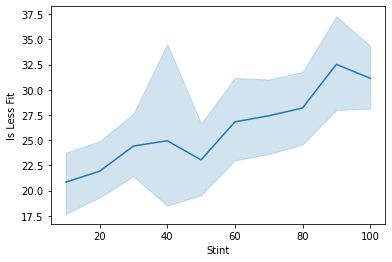

In [14]:
sns.lineplot(
    data=dfxx,
    x="Stint",
    y="Is Less Fit",
    # hue="Series",
    estimator=np.mean,
)


<AxesSubplot:xlabel='Stint', ylabel='Is Less Fit'>

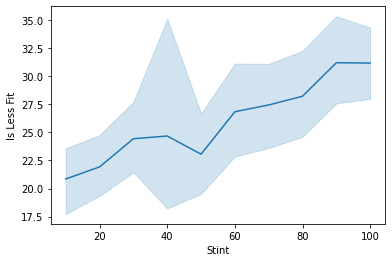

In [15]:
sns.lineplot(
    data=dfxx[
        dfxx["Is More Fit"] < 100
    ],
    x="Stint",
    y="Is Less Fit",
    # hue="Series",
    estimator=np.mean,
)


<AxesSubplot:xlabel='Stint', ylabel='diff'>

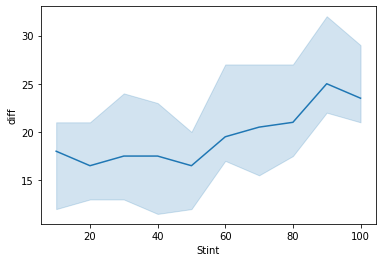

In [16]:
sns.lineplot(
    data=dfxx,
    x="Stint",
    y="diff",
    # hue="Series",
    estimator=np.median,
)


<AxesSubplot:xlabel='Stint', ylabel='Is Less Fit'>

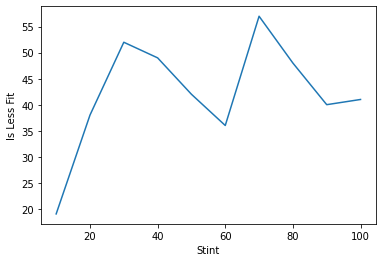

In [17]:
sns.lineplot(
    data=dfxx[dfxx["Series"] == 16005],
    x="Stint",
    y="Is Less Fit",
    # hue="Series",
    estimator=np.median,
)


In [18]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfnone = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfnone["kind"] = "none"
print(dfnone["Competition Stint"].unique())
print(dfnone["Competition Series"].unique())


[  1  10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24
  25  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40
  41  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57
  58  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9
  90  91  92  93  94  95  96  97  98  99]
[16005 16000 16001 16002 16003 16004 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [19]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfbio = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfbio["kind"] = "eco"
print(dfbio["Competition Stint"].unique())
print(dfbio["Competition Series"].unique())


[ 10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24  25
  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40  41
  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57  58
  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73  74
  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9  90
  91  92  93  94  95  96  97  98  99]
[16000 16001 16002 16003 16004 16005 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [20]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfabio = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions-focalbb/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfabio["kind"] = "self"
print(dfabio["Competition Stint"].unique())
print(dfabio["Competition Series"].unique())


[  1  10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24
  25  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40
  41  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57
  58  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9
  90  91  92  93  94  95  96  97  98  99]
[16005 16000 16001 16002 16003 16004 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [21]:
dfx = pd.concat([dfabio, dfbio, dfnone], ignore_index=True)
dfx["Fitness Differential Focal Sign"] = np.sign(
    dfx["Fitness Differential Focal"],
)
dfx["Series"] = dfx["Competition Series"]
dfx["Stint"] = dfx["Competition Stint"]
dfx["flip series"] = dfx["genome series"] * (dfx["Root ID"] == 1)
dfx["Competitor"] = (
    dfx
    .groupby(["Stint", "Series", "kind", "Competition Repro"])
    ["flip series"]
    .transform("max")
)
dfx = dfx[
    dfx["Root ID"] == 0
].groupby(["Stint", "Series", "kind", "Competitor"])[
    "Focal Prevalence"
].mean().round().reset_index(drop=False)
dfx


,Stint,Series,kind,Competitor,Focal Prevalence
0,1,16005,none,16000,1.0
1,1,16005,none,16001,0.0
2,1,16005,none,16002,0.0
3,1,16005,none,16003,0.0
4,1,16005,none,16004,0.0
...,...,...,...,...,...
59117,100,16039,self,16035,0.0
59118,100,16039,self,16036,1.0
59119,100,16039,self,16037,0.0
59120,100,16039,self,16038,0.0


In [22]:
dfxx["Flagged Advantageous Sites"] = dfxx["Is Less Fit"]
dfxx["Flagged Deleterious Sites"] = dfxx["Is More Fit"]

dfj = dfx.join(
    dfxx[
        [
            "Stint",
            "Series",
            "Flagged Advantageous Sites",
            "Flagged Deleterious Sites",
        ]
    ].set_index(
        ["Stint", "Series"]
    ),
    on=["Stint", "Series"],
    how="inner",
).reset_index(drop=False)
dfj["Favored"] = dfj["Focal Prevalence"] > 0.5
dfj


,index,Stint,Series,kind,Competitor,Focal Prevalence,Flagged Advantageous Sites,Flagged Deleterious Sites,Favored
0,1040,10,16000,eco,16000,1.0,16,4,True
1,1041,10,16000,eco,16001,1.0,16,4,True
2,1042,10,16000,eco,16002,0.0,16,4,False
3,1043,10,16000,eco,16003,0.0,16,4,False
4,1044,10,16000,eco,16004,0.0,16,4,False
...,...,...,...,...,...,...,...,...,...
47755,59117,100,16039,self,16035,0.0,27,3,False
47756,59118,100,16039,self,16036,1.0,27,3,True
47757,59119,100,16039,self,16037,0.0,27,3,False
47758,59120,100,16039,self,16038,0.0,27,3,False


In [23]:
light_palette=[
    "#a3cf73",
    "#6dceb1",
]
dark_palette=[
    "#4a772f",
    "#137177",
]


teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=early+x=genotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=early+x=genotype-complexity+y=focal-prevalence+ext=.png


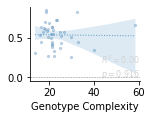

teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=early+x=genotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=early+x=genotype-complexity+y=focal-prevalence+ext=.png


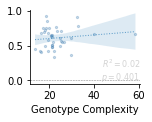

teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=early+x=genotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=early+x=genotype-complexity+y=focal-prevalence+ext=.png


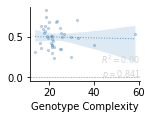

teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=late+x=genotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=late+x=genotype-complexity+y=focal-prevalence+ext=.png


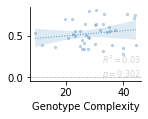

teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=late+x=genotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=late+x=genotype-complexity+y=focal-prevalence+ext=.png


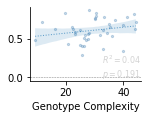

teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=late+x=genotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=late+x=genotype-complexity+y=focal-prevalence+ext=.png


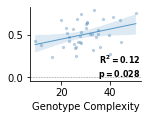

teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=all+x=genotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=all+x=genotype-complexity+y=focal-prevalence+ext=.png


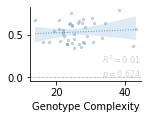

teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=all+x=genotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=all+x=genotype-complexity+y=focal-prevalence+ext=.png


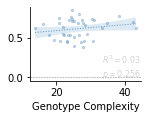

teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=all+x=genotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-02-04-cryptic-complexity/viz=lmplot+when=all+x=genotype-complexity+y=focal-prevalence+ext=.png


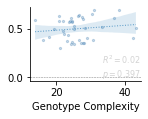

In [24]:
import itertools as it

for (y, when, kind) in it.product(
    ["Focal Prevalence"],
    ["early", "late", "all"],
    ["eco", "self", "none"],
):
    # 1. Base Aggregation
    dfjx = dfj.dropna().groupby(
        ["Series", "kind", "Stint"],
    ).mean().reset_index(drop=False)

    # 2. Separate Baseline (eco) and Target (self)
    # Note: Using 'eco' as baseline per your snippet
    df_kind = dfjx[dfjx["kind"] == kind].copy()

    df_diff = df_kind

    # 4. Calculate Difference
    df_diff["Genotype Complexity"] = df_diff["Flagged Advantageous Sites"]

    # 5. Prepare Plot Data (Aggregated)
    whenisin = {
        "early": range(0, 51, 10),
        "late": range(60, 101, 10),
        "all": range(0, 101, 10),
    }[when]
    df_plot = df_diff[
        df_diff["Stint"].isin(whenisin)
    ].groupby(["Series"]).mean().reset_index(drop=False)

    # 6. Calculate Regression Stats
    slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(
        df_plot["Genotype Complexity"],
        df_plot[y]
    )

    # Determine significance
    is_significant = p_value < 0.05

    # Format the annotation text with bold if significant
    if is_significant:
        stats_text = (
            f"$\\mathbf{{R^2 = {r_value**2:.2f}}}$\n"
            f"$\\mathbf{{p = {p_value:{'.1e' if p_value < 0.01 else '.3f'}}}}$"
        )
    else:
        stats_text = (
            f"$R^2 = {r_value**2:.2f}$\n"
            f"$p = {p_value:{'.1e' if p_value < 0.01 else '.3f'}}$"
        )

    # 7. Plot
    with tp.teed(
        sns.lmplot,
        data=df_plot,
        x="Genotype Complexity",
        y=y,
        line_kws={"lw": 1.0, "alpha": 0.7, "color": "C0", "linestyle": '-' if is_significant else ':'},
        facet_kws=dict(
            sharex=False,
            sharey=True,
        ),
        scatter_kws={"alpha": 0.3, "clip_on": False, "s": 5, "color": "steelblue"},
        teeplot_outattrs={"when": when},
        teeplot_subdir=teeplot_subdir,
    ) as g:
        g.figure.set_size_inches(2, 1.2)  # Adjusted size for single plot
        g.set_xlabels("Genotype Complexity")
        g.set_ylabels("")

        # Add a horizontal reference line
        ax = g.axes.flat[0]
        ax.axhline(0, color="k", ls="--", lw=0.5, alpha=0.5)
        # ax.set_ylim(-0.18, 0.42)

        # Add the stats annotation to the plot
        # Anchored to upper left or right depending on data layout
        g.figure.subplots_adjust(left=0.2)
        ax.text(
            1, 0,
            stats_text,
            transform=ax.transAxes,
            horizontalalignment='right',
            verticalalignment='bottom',
            fontsize=8,
            color="black" if is_significant else "lightgray",
            weight="bold" if is_significant else "normal",
        )
